# Exercise for Unit 5 — Skip-gram with Negative Sampling

**Name:** MEAGELLEINE ROSE S. SIONOSA

---

Train a word embedding model using the skip-gram architecture with negative sampling, then evaluate whether the learned vectors capture useful semantic relationships.

**Wikipedia article used:** [Naruto](https://en.wikipedia.org/wiki/Naruto)

## Imports and Setup

In [1]:
"""
Train Skip-gram with Negative Sampling on a Wikipedia article,
then evaluate the embedding model with intrinsic tests and custom test sets.

Requirements:
    pip install requests beautifulsoup4 nltk gensim scikit-learn scipy

Optional:
    python -m nltk.downloader punkt stopwords
"""

import re
import math
import json
import random
from collections import Counter
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

RANDOM_SEED = 42

---
## Step 1 — Select a Wikipedia Article as the Corpus


In [2]:
# ─── STEP 1: Wikipedia article selection ───────────────────────────────────
# Code line reference: WIKI_URL constant + fetch_wikipedia_article() function

WIKI_URL = "https://en.wikipedia.org/wiki/Naruto" 

def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)


def fetch_wikipedia_article(url: str) -> str:
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; SGNS-Naruto-Training/1.0)"
    }
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, "html.parser")
    content_div = soup.find("div", {"id": "mw-content-text"})
    if content_div is None:
        raise ValueError("Could not find Wikipedia article content.")

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = []
    for p in paragraphs:
        txt = p.get_text(" ", strip=True)
        if txt:
            text_blocks.append(txt)

    text = "\n".join(text_blocks)
    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


ensure_nltk()
print("Downloading Wikipedia article:", WIKI_URL)
raw_text = fetch_wikipedia_article(WIKI_URL)
print(f"Article fetched — {len(raw_text):,} characters.")


Article fetched — 62,487 characters.


---
## Step 2 — Preprocess the Text


In [3]:
# ─── STEP 2: Preprocessing ─────────────────────────────────────────────────
# Code line reference: preprocess_text() function

def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)
    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue
        tokens = word_tokenize(sent)
        cleaned = []
        for tok in tokens:
            tok = tok.strip("-")
            if not tok:
                continue
            if tok.isdigit():
                continue
            if len(tok) < 2:
                continue
            cleaned.append(tok)
        if len(cleaned) >= 3:
            processed.append(cleaned)
    return processed


def corpus_stats(sentences: List[List[str]]) -> Dict[str, int]:
    flat = [w for s in sentences for w in s]
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(set(flat)),
    }


print("Preprocessing text...")
sentences = preprocess_text(raw_text)
stats = corpus_stats(sentences)

print("\n=== Corpus Stats ===")
for k, v in stats.items():
    print(f"  {k}: {v}")

Preprocessing text...

=== Corpus Stats ===
  num_sentences: 667
  num_tokens: 7970
  vocab_size: 2040


---
## Step 3 — Train a Skip-gram with Negative Sampling (SGNS)

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `vector_size` | **100** | Dimensionality of each word embedding |
| `window` | **5** | Context window — words within ±5 positions are considered neighbours |
| `sg` | **1** | Architecture: 1 = Skip-gram (0 = CBOW) |
| `negative` | **10** | Number of negative samples per positive example |
| `epochs` | 200 | Training passes over the corpus |

In [4]:
# ─── STEP 3: Train Skip-gram with Negative Sampling ────────────────────────
# Code line reference: train_sgns() function

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

def train_sgns(sentences: List[List[str]], vector_size=100, window=5) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,   # embedding dimensionality
        window=window,             # context window size
        min_count=1,
        workers=4,
        sg=1,                      # 1 = skip-gram
        negative=10,               # negative sampling
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )
    return model


print("Training Skip-gram (vector_size=100, window=5) ...")
model = train_sgns(sentences, vector_size=100, window=5)
print(f"Training complete. Vocabulary size: {len(model.wv)}")

Training Skip-gram (vector_size=100, window=5) ...
Training complete. Vocabulary size: 2040


---
## Step 4 — Evaluate Embeddings Using a Small Test Set


In [5]:
# ─── STEP 4: Evaluation functions ──────────────────────────────────────────
# Code line reference: evaluate_relatedness() and evaluate_analogies() functions

def has_word(model, word):
    return word in model.wv.key_to_index

def cosine_sim(model, w1, w2):
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])

def evaluate_relatedness(model, test_pairs):
    covered = []
    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine_sim(model, w1, w2)
            covered.append((w1, w2, score, sim))
    return {"covered_items": covered, "coverage": len(covered), "total": len(test_pairs)}

def evaluate_analogies(model, analogies):
    covered = correct = 0
    details = []
    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            try:
                preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
                predicted_words = [w for w, _ in preds]
                hit = d in predicted_words
                correct += int(hit)
                details.append({"analogy": f"{a}:{b}::{c}:?", "expected": d,
                                 "predictions": predicted_words, "correct_in_top5": hit})
            except KeyError:
                pass
    accuracy = correct / covered if covered else float("nan")
    return {"coverage": covered, "total": len(analogies),
            "accuracy_top5": accuracy, "details": details}


# ── Relatedness test set (Naruto domain) ─────────────────────────────────
relatedness_test = [
    ("naruto",   "ninja",    0.90),   # naruto is a ninja
    ("naruto",   "hokage",   0.85),   # naruto's goal is to become hokage
    ("chakra",   "jutsu",    0.90),   # chakra is used to perform jutsu
    ("sasuke",   "naruto",   0.80),   # rival/partner characters
    ("anime",    "manga",    0.90),   # same media franchise
    ("village",  "clan",     0.75),   # related community terms
    ("shinobi",  "ninja",    0.95),   # near-synonyms in the series
    ("battle",   "fight",    0.85),   # combat terms
    ("naruto",   "kitchen",  0.02),   # unrelated
    ("chakra",   "tractor",  0.02),   # unrelated
    ("manga",    "episode",  0.40),   # loosely related media terms
    ("sakura",   "sasuke",   0.60),   # team members
]

rel_results = evaluate_relatedness(model, relatedness_test)
print("=== Relatedness Test Set ===")
print(f"Coverage: {rel_results['coverage']}/{rel_results['total']}")
for w1, w2, gold, pred in rel_results["covered_items"]:
    match = "✓" if (gold >= 0.5) == (pred >= 0.5) else "✗"
    print(f"  {match} {w1:10s} - {w2:10s} | gold={gold:.2f}  pred={pred:.4f}")


=== Relatedness Test Set ===
Coverage: 10/12
  ✗ naruto     - ninja      | gold=0.90  pred=0.1655
  ✗ naruto     - hokage     | gold=0.85  pred=0.2538
  ✗ chakra     - jutsu      | gold=0.90  pred=0.3125
  ✗ sasuke     - naruto     | gold=0.80  pred=0.1909
  ✗ anime      - manga      | gold=0.90  pred=0.3000
  ✗ village    - clan       | gold=0.75  pred=0.4352
  ✗ shinobi    - ninja      | gold=0.95  pred=0.2581
  ✗ battle     - fight      | gold=0.85  pred=0.3824
  ✓ manga      - episode    | gold=0.40  pred=0.1432
  ✗ sakura     - sasuke     | gold=0.60  pred=0.4293


In [6]:
# ── Analogy test set (Naruto domain) ─────────────────────────────────────
analogy_test = [
    ("naruto",  "hokage",  "sasuke",  "avenger"),   # goal/title analogy
    ("ninja",   "chakra",  "shinobi", "jutsu"),      # warrior:power analogy
    ("anime",   "manga",   "series",  "chapter"),    # media format analogy
    ("village", "clan",    "hokage",  "leader"),     # community:leader analogy
]

analogy_results = evaluate_analogies(model, analogy_test)
print("=== Analogy Test Set ===")
print(f"Coverage: {analogy_results['coverage']}/{analogy_results['total']}")
print(f"Top-5 accuracy: {analogy_results['accuracy_top5']:.2f}")
for item in analogy_results["details"]:
    print(json.dumps(item, ensure_ascii=False))


=== Analogy Test Set ===
Coverage: 3/4
Top-5 accuracy: 0.00
{"analogy": "ninja:chakra::shinobi:?", "expected": "jutsu", "predictions": ["amount", "might", "results", "decision", "energy"], "correct_in_top5": false}
{"analogy": "anime:manga::series:?", "expected": "chapter", "predictions": ["ability", "best-selling", "fluidity", "blow", "away"], "correct_in_top5": false}
{"analogy": "village:clan::hokage:?", "expected": "leader", "predictions": ["holds", "disable", "ability", "member", "crimes"], "correct_in_top5": false}


---
## Step 5 — Report Nearest Neighbours, Similarity Scores, and Test-Set Performance


In [7]:
# ─── STEP 5: Report nearest neighbours ─────────────────────────────────────
# Code line reference: print_top_neighbors() function + direct similarity checks

def print_top_neighbors(model, words, topn=8):
    print("\n=== Nearest Neighbors ===")
    for word in words:
        if has_word(model, word):
            neighbors = model.wv.most_similar(word, topn=topn)
            print(f"\n  {word}:")
            for neigh, score in neighbors:
                print(f"    {neigh:22s}  {score:.4f}")
        else:
            print(f"\n  {word}: [OOV — not in vocabulary]")


probe_words = ["naruto", "ninja", "chakra", "jutsu", "hokage",
               "sasuke", "village", "shinobi", "manga", "anime"]
print_top_neighbors(model, probe_words, topn=8)

print("\n=== Direct Similarity Checks ===")
check_pairs = [
    ("naruto",  "hokage"),
    ("chakra",  "jutsu"),
    ("shinobi", "ninja"),
    ("naruto",  "kitchen"),
]
for w1, w2 in check_pairs:
    if has_word(model, w1) and has_word(model, w2):
        print(f"  {w1:10s} <-> {w2:10s}: {cosine_sim(model, w1, w2):.4f}")
    else:
        print(f"  {w1:10s} <-> {w2:10s}: OOV")



=== Nearest Neighbors ===

  naruto:
    42-44                   0.3772
    gn                      0.3714
    person                  0.3693
    clinic                  0.3632
    letter                  0.3578
    midwest                 0.3512
    tin                     0.3507
    mangalife               0.3463

  ninja:
    hands-on                0.5833
    updated                 0.5805
    council                 0.5684
    clash                   0.5569
    under                   0.5277
    taisen                  0.5239
    era                     0.5238
    coin                    0.5193

  chakra:
    might                   0.8993
    energy                  0.8726
    amount                  0.8710
    concerned               0.8607
    make                    0.8577
    creature                0.7766
    overly                  0.7662
    giant                   0.7444

  jutsu:
    magical                 0.7571
    abilities               0.7543
    type             

---
## Update 1 — Retrain with Window Size = 10

In [8]:
# ─── UPDATE 1: Retrain with window=10 ──────────────────────────────────────

print("Retraining with window=10 ...")
model_w10 = train_sgns(sentences, vector_size=100, window=10)
print(f"New model vocabulary size: {len(model_w10.wv)}")

rel_old = evaluate_relatedness(model,     relatedness_test)
rel_new = evaluate_relatedness(model_w10, relatedness_test)

print("\n=== Relatedness Comparison: window=5 (OLD) vs window=10 (NEW) ===")
print(f"{'Pair':<25} {'Gold':>6} {'OLD sim':>9} {'NEW sim':>9} {'Δ':>8}")
print("-" * 62)
old_map = {(w1,w2): pred for w1,w2,gold,pred in rel_old["covered_items"]}
for w1, w2, gold, pred_new in rel_new["covered_items"]:
    pred_old = old_map.get((w1,w2), float("nan"))
    delta = pred_new - pred_old
    print(f"{w1+' - '+w2:<25} {gold:>6.2f} {pred_old:>9.4f} {pred_new:>9.4f} {delta:>+8.4f}")

Retraining with window=10 ...
New model vocabulary size: 2040

=== Relatedness Comparison: window=5 (OLD) vs window=10 (NEW) ===
Pair                        Gold   OLD sim   NEW sim        Δ
--------------------------------------------------------------
naruto - ninja              0.90    0.1655    0.1325  -0.0330
naruto - hokage             0.85    0.2538    0.2209  -0.0329
chakra - jutsu              0.90    0.3125    0.2804  -0.0321
sasuke - naruto             0.80    0.1909    0.1764  -0.0146
anime - manga               0.90    0.3000    0.2797  -0.0203
village - clan              0.75    0.4352    0.4322  -0.0030
shinobi - ninja             0.95    0.2581    0.2531  -0.0051
battle - fight              0.85    0.3824    0.1783  -0.2040
manga - episode             0.40    0.1432    0.1304  -0.0128
sakura - sasuke             0.60    0.4293    0.3510  -0.0783


---
## Update 2 — PCA Visualisation of Word Vectors

Words in vocabulary for PCA: ['naruto', 'sasuke', 'sakura', 'kakashi', 'hokage', 'ninja', 'shinobi', 'chakra', 'jutsu', 'clan', 'village', 'battle', 'fight', 'manga', 'anime', 'series', 'character', 'story', 'japan', 'power', 'team', 'training', 'sensei']


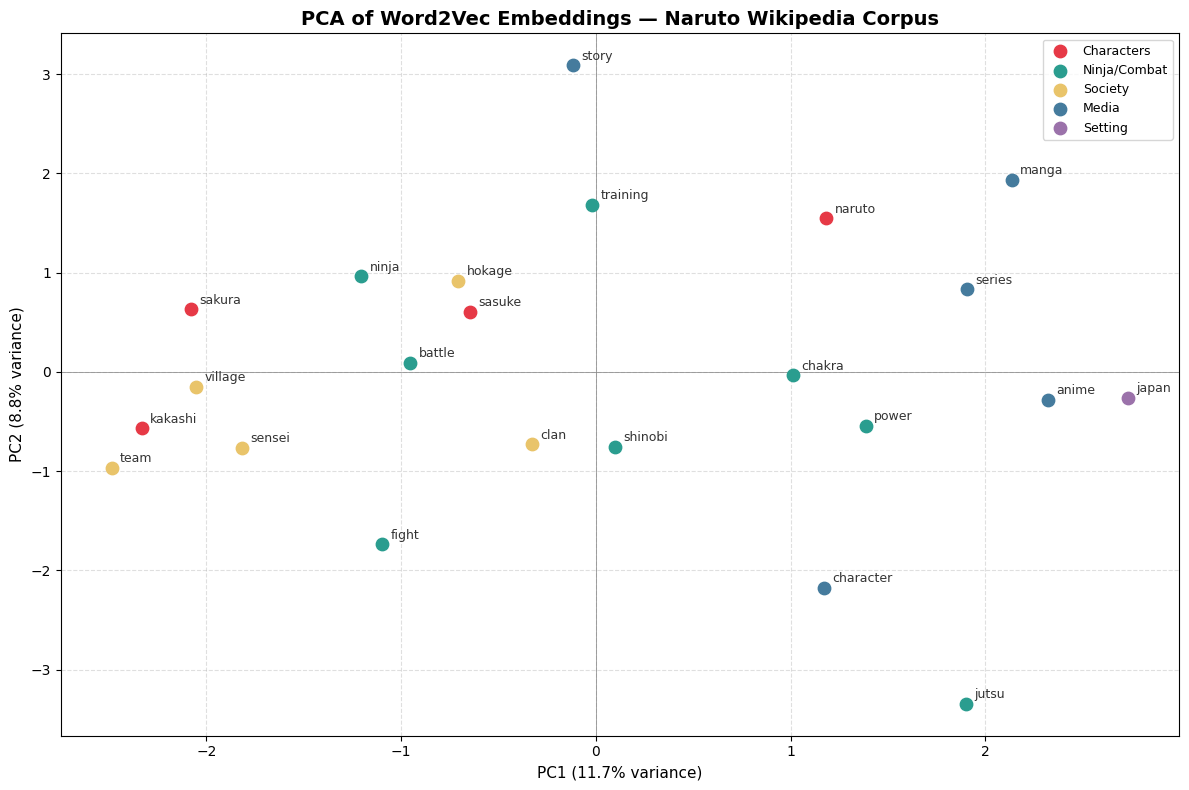

PCA plot saved to pca_embeddings.png


In [ ]:
# ─── UPDATE 2: PCA Visualisation ───────────────────────────────────────────

# 20 known Naruto-domain words for the visualisation
vis_words = [
    "naruto",  "sasuke",  "sakura",  "kakashi", "hokage",
    "ninja",   "shinobi", "chakra",  "jutsu",   "clan",
    "village", "battle",  "fight",   "manga",   "anime",
    "series",  "character","story",  "japan",   "power",
    "team",    "enemy",   "training","sensei"
]

# Keep only words present in the vocabulary
vis_words = [w for w in vis_words if has_word(model, w)]
print(f"Words in vocabulary for PCA: {vis_words}")

# Extract embedding vectors
vectors = np.array([model.wv[w] for w in vis_words])

# Reduce to 2D with PCA
pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(vectors)
explained = pca.explained_variance_ratio_

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

groups = {
    "Characters":   ["naruto", "sasuke", "sakura", "kakashi"],
    "Ninja/Combat": ["ninja", "shinobi", "chakra", "jutsu", "battle", "fight", "power", "training", "enemy"],
    "Society":      ["hokage", "clan", "village", "team", "sensei"],
    "Media":        ["manga", "anime", "series", "character", "story"],
    "Setting":      ["japan"],
}
colors = {"Characters": "#E63946", "Ninja/Combat": "#2A9D8F",
          "Society": "#E9C46A", "Media": "#457B9D", "Setting": "#9B72AA"}

word_to_idx = {w: i for i, w in enumerate(vis_words)}
for group, words in groups.items():
    idxs = [word_to_idx[w] for w in words if w in word_to_idx]
    if not idxs:
        continue
    xs = coords[idxs, 0]
    ys = coords[idxs, 1]
    ax.scatter(xs, ys, color=colors[group], s=80, zorder=3, label=group)
    for w, x, y in zip([vis_words[i] for i in idxs], xs, ys):
        ax.annotate(w, (x, y), textcoords="offset points", xytext=(6, 4),
                    fontsize=9, color="#333333")

ax.set_title("PCA of Word2Vec Embeddings — Naruto Wikipedia Corpus", fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)", fontsize=11)
ax.legend(loc="best", fontsize=9, framealpha=0.8)
ax.grid(True, linestyle="--", alpha=0.4)
ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)

plt.tight_layout()
plt.savefig("pca_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()
print("PCA plot saved to pca_embeddings.png")
